# **Pip Installs**

In [1]:
!pip install geopy
!pip install pycorr

# **Imports**

In [2]:
# Master Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import chi2_contingency
from geopy.distance import geodesic
from collections import Counter
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc,  mean_squared_error, r2_score, mutual_info_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn import datasets, linear_model
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Naive Bayes
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# KNN
from sklearn.neighbors import KNeighborsClassifier

# SVM
from sklearn.svm import SVC

# Ensemble Boosting
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, GradientBoostingClassifier


# Simple Neural Network
from sklearn.neural_network import MLPClassifier

# ignore the warning messages
import warnings
warnings.filterwarnings('ignore')

# **DataSet Import**

In [3]:
data = "https://drive.google.com/file/d/1r92kOaqpY79043f0mlWez6MoztmljSeP/view?usp=sharing".split('/')[-2]
data = f"https://drive.google.com/uc?id={data}"
df = pd.read_csv(data)

# **Exploratory Data Analysis & Minor Pre Processing**

In [4]:
df.head(20)

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Electric Utility,2020 Census Tract,Longitude,latitude
0,Thurston,Tumwater,WA,98512,2019,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,220,0,22,242565116,PUGET SOUND ENERGY INC,53067010910,-122.913102,47.013593
1,Island,Clinton,WA,98236,2022,NISSAN,LEAF,Battery Electric Vehicle,Eligibility unknown as battery range has not b...,0,0,10,183272785,PUGET SOUND ENERGY INC,53029972000,-122.359364,47.979655
2,Snohomish,Snohomish,WA,98290,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,266,0,44,112552366,PUGET SOUND ENERGY INC,53061052502,-122.091505,47.915555
3,King,Seattle,WA,98134,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,322,0,11,6336319,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033009300,-122.329815,47.579810
4,Snohomish,Edmonds,WA,98020,2013,TESLA,MODEL S,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,208,69900,21,186212960,PUGET SOUND ENERGY INC,53061050403,-122.375070,47.808070
5,Chelan,Manson,WA,98831,2018,BMW,I3,Plug-in Hybrid Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,97,0,12,215122904,PUD NO 1 OF CHELAN COUNTY,53007960400,-120.153100,47.885505
6,Snohomish,Marysville,WA,98271,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,308,0,38,110992472,PUGET SOUND ENERGY INC,53061053102,-122.171385,48.104330
7,Snohomish,Edmonds,WA,98026,2021,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle,Not eligible due to low battery range,18,0,21,138909032,PUGET SOUND ENERGY INC,53061050300,-122.335685,47.803720
8,Thurston,Olympia,WA,98501,2019,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle,Not eligible due to low battery range,25,0,22,272310279,PUGET SOUND ENERGY INC,53067010700,-122.896920,47.043535
9,Thurston,Lacey,WA,98503,2018,NISSAN,LEAF,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,151,0,22,235573929,PUGET SOUND ENERGY INC,53067011422,-122.828500,47.036460


**Feature Observation**

---
*   State column is unnecessary (Since we are working with Washington only)
*   Base MSRP has way too many 0 values in it, possibly placeholder for NaN; needs further investigations.
*  DOL Vehicle ID is unnecessary (Unique Identifier)
*  We have too many features to track the registration location of the vehicle (County, City, Postal Code, Legislative District, 2020 Census Tract, Longitude & Latitude)



In [5]:
df.shape

(134474, 17)

Dropping unnecessary columns

In [6]:
df = df.drop(['State', 'DOL Vehicle ID'], axis=1)

In [7]:
df.head(5)

,County,City,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV,Electric Range,Base MSRP,Legislative District,Electric Utility,2020 Census Tract,Longitude,latitude
0,Thurston,Tumwater,98512,2019,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,220,0,22,PUGET SOUND ENERGY INC,53067010910,-122.913102,47.013593
1,Island,Clinton,98236,2022,NISSAN,LEAF,Battery Electric Vehicle,Eligibility unknown as battery range has not b...,0,0,10,PUGET SOUND ENERGY INC,53029972000,-122.359364,47.979655
2,Snohomish,Snohomish,98290,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,266,0,44,PUGET SOUND ENERGY INC,53061052502,-122.091505,47.915555
3,King,Seattle,98134,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,322,0,11,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033009300,-122.329815,47.579810
4,Snohomish,Edmonds,98020,2013,TESLA,MODEL S,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,208,69900,21,PUGET SOUND ENERGY INC,53061050403,-122.375070,47.808070


In [8]:
df.dtypes

County                    object
City                      object
Postal Code                int64
Model Year                 int64
Make                      object
Model                     object
Electric Vehicle Type     object
CAFV                      object
Electric Range             int64
Base MSRP                  int64
Legislative District       int64
Electric Utility          object
2020 Census Tract          int64
Longitude                float64
latitude                 float64
dtype: object

In [9]:
df.isnull().sum()

County                   0
City                     0
Postal Code              0
Model Year               0
Make                     0
Model                    0
Electric Vehicle Type    0
CAFV                     0
Electric Range           0
Base MSRP                0
Legislative District     0
Electric Utility         0
2020 Census Tract        0
Longitude                0
latitude                 0
dtype: int64

In [10]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,2020 Census Tract,Longitude,latitude
count,134474.000000,134474.000000,134474.000000,134474.000000,134474.000000,1.344740e+05,134474.000000,134474.000000
mean,98259.228520,2019.657250,74.730208,1451.396069,29.499911,5.303964e+10,-122.092668,47.467715
std,303.069045,3.001443,98.776037,9691.900720,14.786294,1.617660e+07,1.006671,0.615275
min,98001.000000,1997.000000,0.000000,0.000000,1.000000,5.300195e+10,-124.625140,45.583863
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,5.303301e+10,-122.405565,47.357985
50%,98122.000000,2021.000000,21.000000,0.000000,34.000000,5.303303e+10,-122.296385,47.613850
75%,98370.000000,2022.000000,150.000000,0.000000,43.000000,5.305307e+10,-122.151665,47.715580
max,99403.000000,2024.000000,337.000000,845000.000000,49.000000,5.307794e+10,-117.044370,48.996340


Observations
*   Postal Codes are of 5 digits. First two digits indicate the state. 98 and 99 points to Washington, since max of Postal code is 99403 and min is 98001, so it is sure that all the Postal codes are of Washington. Now we can change the data in such way that it is easier to encode.
*   Our oldest vehicles are from 1997 and newest ones are from 2024
*   Electric Range of 0 is not possible for Electric vehicles, so we can assume that 0 is a placeholder for NaN, we have to handle that.
*   Base MSRP has no value above 0 for more than 75% of its dataset. Needs further investigation, possibly large amount of data missing.
*   We will use Longitude and Latitude for a more generalized distance measurement over Census Tract to avoid overfitting.



In [11]:
df = df.drop(['2020 Census Tract'], axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134474 entries, 0 to 134473
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   County                 134474 non-null  object 
 1   City                   134474 non-null  object 
 2   Postal Code            134474 non-null  int64  
 3   Model Year             134474 non-null  int64  
 4   Make                   134474 non-null  object 
 5   Model                  134474 non-null  object 
 6   Electric Vehicle Type  134474 non-null  object 
 7   CAFV                   134474 non-null  object 
 8   Electric Range         134474 non-null  int64  
 9   Base MSRP              134474 non-null  int64  
 10  Legislative District   134474 non-null  int64  
 11  Electric Utility       134474 non-null  object 
 12  Longitude              134474 non-null  float64
 13  latitude               134474 non-null  float64
dtypes: float64(2), int64(5), object(7)
m

<Axes: xlabel='Base MSRP', ylabel='Count'>

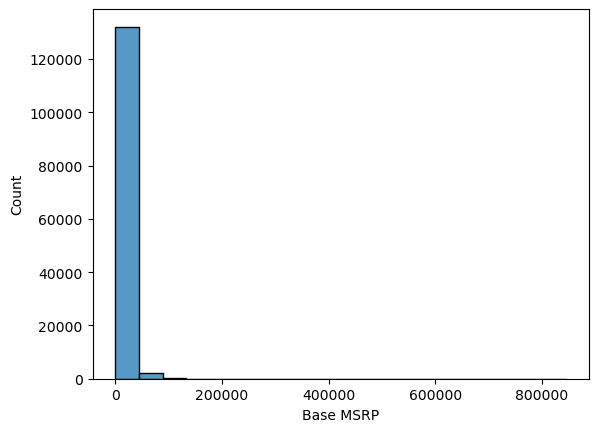

In [13]:
sns.histplot(df, x = "Base MSRP" , palette='pastel')

<Axes: xlabel='Base MSRP'>

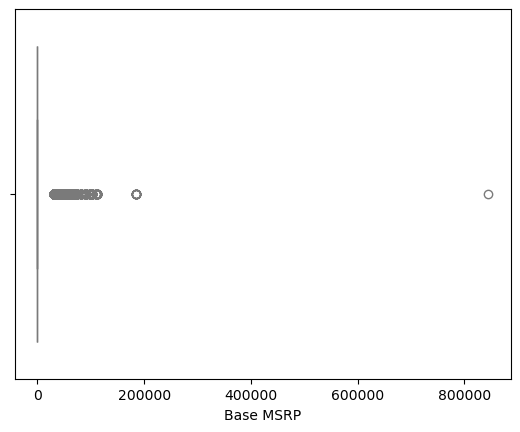

In [14]:
sns.boxplot(df, x = 'Base MSRP', palette='pastel')

In [15]:
df['Base MSRP'].unique()

array([     0,  69900,  52900,  45600,  36900,  44100,  31950,  52650,
        32250,  39995,  59900,  54950, 110950,  64950,  89100,  32995,
        34995, 184400,  36800,  33950, 102000,  90700, 109000,  98950,
        55700,  53400,  75095,  91250,  81100,  43700, 845000],
      dtype=int64)

In [16]:
df['Base MSRP'].value_counts()

Base MSRP
0         131055
69900       1430
31950        400
52900        214
32250        152
54950        136
59900        127
39995        121
36900        100
44100         96
64950         86
45600         75
33950         74
52650         63
34995         63
55700         51
36800         49
53400         36
110950        20
98950         19
81100         18
75095         16
90700         16
102000        15
43700         11
184400        11
109000         7
89100          6
32995          3
91250          3
845000         1
Name: count, dtype: int64

In [17]:
zeros = (df['Base MSRP']==0).sum()
base_msrp_missing = round((1 - (abs((df.shape[0]-zeros)/df.shape[0])))*100,2)
base_msrp_missing

97.46

Too much Base MSRP values are missing, we will drop it for now.

In [18]:
df = df.drop(['Base MSRP'], axis=1)

In [19]:
df['Electric Range'].value_counts().head(20)

Electric Range
0      56618
215     6422
220     4150
84      4036
238     3508
25      3231
19      2534
208     2499
53      2487
291     2367
21      2347
38      2262
32      2216
75      1942
210     1907
322     1708
266     1460
30      1419
150     1380
42      1337
Name: count, dtype: int64

Almost half of the values are 0 for Electric Range, an electric vehicle cannot have a range of 0. This is a placeholder for NaN values.

In [20]:
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)

<Axes: xlabel='Electric Range', ylabel='Count'>

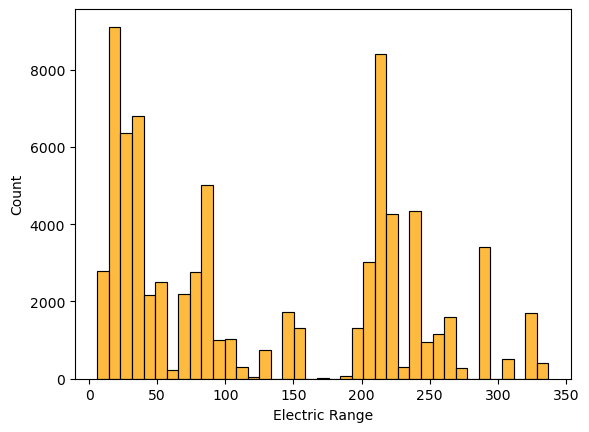

In [21]:
sns.histplot(df, x = 'Electric Range', color='Orange')

In [22]:
df['Electric Vehicle Type'].value_counts()

Electric Vehicle Type
Battery Electric Vehicle              103424
Plug-in Hybrid Electric Vehicle        31050
Name: count, dtype: int64

Plug-in Hybrid Electric Vehicle (PHEV) and Battery Electric Vehicle (BEV) are different types of vehicle. They have different architecture, and thus we should treat their Range differently.

We will make two separate features, one for PHEV range another for BEV range

In [23]:
df.head(10)

,County,City,Postal Code,Model Year,Make,Model,Electric Vehicle Type,CAFV,Electric Range,Legislative District,Electric Utility,Longitude,latitude
0,Thurston,Tumwater,98512,2019,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,220.0,22,PUGET SOUND ENERGY INC,-122.913102,47.013593
1,Island,Clinton,98236,2022,NISSAN,LEAF,Battery Electric Vehicle,Eligibility unknown as battery range has not b...,NaN,10,PUGET SOUND ENERGY INC,-122.359364,47.979655
2,Snohomish,Snohomish,98290,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,266.0,44,PUGET SOUND ENERGY INC,-122.091505,47.915555
3,King,Seattle,98134,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,322.0,11,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),-122.329815,47.579810
4,Snohomish,Edmonds,98020,2013,TESLA,MODEL S,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,208.0,21,PUGET SOUND ENERGY INC,-122.375070,47.808070
5,Chelan,Manson,98831,2018,BMW,I3,Plug-in Hybrid Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,97.0,12,PUD NO 1 OF CHELAN COUNTY,-120.153100,47.885505
6,Snohomish,Marysville,98271,2020,TESLA,MODEL 3,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,308.0,38,PUGET SOUND ENERGY INC,-122.171385,48.104330
7,Snohomish,Edmonds,98026,2021,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle,Not eligible due to low battery range,18.0,21,PUGET SOUND ENERGY INC,-122.335685,47.803720
8,Thurston,Olympia,98501,2019,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle,Not eligible due to low battery range,25.0,22,PUGET SOUND ENERGY INC,-122.896920,47.043535
9,Thurston,Lacey,98503,2018,NISSAN,LEAF,Battery Electric Vehicle,Clean Alternative Fuel Vehicle Eligible,151.0,22,PUGET SOUND ENERGY INC,-122.828500,47.036460


In [24]:
df['Electric Vehicle Type'] = df['Electric Vehicle Type'].str.strip()

df['BEV Range'] = np.where((df['Electric Vehicle Type'] == 'Battery Electric Vehicle') & (~df['Electric Range'].isna()), df['Electric Range'], np.where(df['Electric Range'].isna(), np.nan, 0))

df['PHEV Range'] = np.where((df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle') & (~df['Electric Range'].isna()), df['Electric Range'], np.where(df['Electric Range'].isna(), np.nan, 0))

In [25]:
bev_mean = df.loc[df['BEV Range'] != 0, 'BEV Range'].mean()
bev_median = df.loc[df['BEV Range'] != 0, 'BEV Range'].median()

phev_mean = df.loc[df['PHEV Range'] != 0, 'PHEV Range'].mean()
phev_median = df.loc[df['PHEV Range'] != 0, 'PHEV Range'].median()

<Axes: xlabel='PHEV Range', ylabel='Count'>

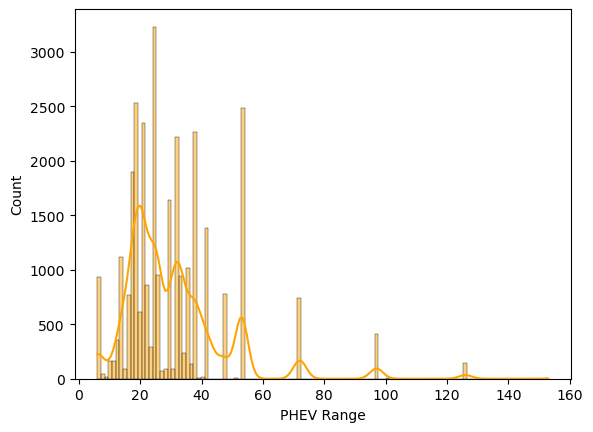

In [26]:
sns.histplot(df, x = df.loc[df['PHEV Range'] != 0, 'PHEV Range'], kde=True, color='Orange'   )

<Axes: xlabel='BEV Range', ylabel='Count'>

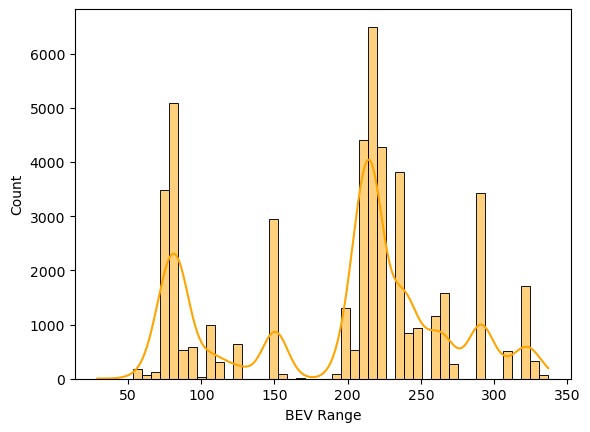

In [27]:
sns.histplot(df, x = df.loc[df['BEV Range'] != 0, 'BEV Range'], kde=True, color='Orange')

In [28]:
df = df.drop(['Electric Vehicle Type', 'Electric Range'], axis=1)

Since we have various ways to pinpoint the location, we can drop County feature as well.

In [29]:
df = df.drop(['County'], axis=1)

In [30]:
df.head(7)

,City,Postal Code,Model Year,Make,Model,CAFV,Legislative District,Electric Utility,Longitude,latitude,BEV Range,PHEV Range
0,Tumwater,98512,2019,TESLA,MODEL 3,Clean Alternative Fuel Vehicle Eligible,22,PUGET SOUND ENERGY INC,-122.913102,47.013593,220.0,0.0
1,Clinton,98236,2022,NISSAN,LEAF,Eligibility unknown as battery range has not b...,10,PUGET SOUND ENERGY INC,-122.359364,47.979655,NaN,NaN
2,Snohomish,98290,2020,TESLA,MODEL 3,Clean Alternative Fuel Vehicle Eligible,44,PUGET SOUND ENERGY INC,-122.091505,47.915555,266.0,0.0
3,Seattle,98134,2020,TESLA,MODEL 3,Clean Alternative Fuel Vehicle Eligible,11,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),-122.329815,47.579810,322.0,0.0
4,Edmonds,98020,2013,TESLA,MODEL S,Clean Alternative Fuel Vehicle Eligible,21,PUGET SOUND ENERGY INC,-122.375070,47.808070,208.0,0.0
5,Manson,98831,2018,BMW,I3,Clean Alternative Fuel Vehicle Eligible,12,PUD NO 1 OF CHELAN COUNTY,-120.153100,47.885505,0.0,97.0
6,Marysville,98271,2020,TESLA,MODEL 3,Clean Alternative Fuel Vehicle Eligible,38,PUGET SOUND ENERGY INC,-122.171385,48.104330,308.0,0.0


In [31]:
df['Electric Utility'].unique()

array(['PUGET SOUND ENERGY INC',
       'CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)',
       'PUD NO 1 OF CHELAN COUNTY', 'PACIFICORP', 'AVISTA CORP',
       'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)',
       'PUD NO 1 OF PEND OREILLE COUNTY', 'PUD NO 1 OF DOUGLAS COUNTY',
       'PUD NO 2 OF GRANT COUNTY', 'MODERN ELECTRIC WATER COMPANY',
       'BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA)',
       'BONNEVILLE POWER ADMINISTRATION||ORCAS POWER & LIGHT COOP',
       'PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY',
       'BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY',
       'BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLALLAM COUNTY',
       'BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF COWLITZ COUNTY',
       'BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOHOMISH COUNTY',
       'BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PUD NO 1 OF LEWIS COUNTY',
       'BONNEVILLE POWER ADMINISTRATION||PACIFICORP||PUD 

Looks like the Electric Utility feature space is not cleaned properly. We will manually clean it to measure correlation properly

In [32]:
df.nunique()

City                    454
Postal Code             530
Model Year               22
Make                     36
Model                   125
CAFV                      3
Legislative District     49
Electric Utility         75
Longitude               529
latitude                530
BEV Range                61
PHEV Range               46
dtype: int64

In [33]:
df['Electric Utility'].value_counts().head(10)

Electric Utility
PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)                                      49285
PUGET SOUND ENERGY INC                                                             26552
CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)                                       24788
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA)                    7808
BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY     6032
PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY                                  3117
BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||INLAND POWER & LIGHT COMPANY          1989
BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOHOMISH COUNTY                          1212
PACIFICORP                                                                           998
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF BENTON COUNTY                           966
Name: count, dtype: int64

In [34]:
df_copy = df.copy()

In [35]:
def clean_electric_utility(df, company_name):
    df_copy['Electric Utility'] = df_copy['Electric Utility'].apply(lambda x: company_name if x.startswith(company_name) else x)
    return df_copy
problems = ['PUGET SOUND ENERGY', 'BONNEVILLE POWER ADMINISTRATION', 'PUD', 'CITY OF']
for i in problems:
    df_cleaned = clean_electric_utility(df_copy, i)

In [36]:
df_cleaned['Electric Utility'] = df_cleaned['Electric Utility'].replace('CITY OF', 'PUD')

In [37]:
df_cleaned['Electric Utility'].value_counts().head(20)

Electric Utility
PUGET SOUND ENERGY                   78954
PUD                                  26812
BONNEVILLE POWER ADMINISTRATION      26269
PACIFICORP                             998
MODERN ELECTRIC WATER COMPANY          852
AVISTA CORP                            288
NO KNOWN ELECTRIC UTILITY SERVICE      190
OKANOGAN COUNTY ELEC COOP, INC         108
PORTLAND GENERAL ELECTRIC CO             3
Name: count, dtype: int64

In [38]:
df_cleaned.nunique()

City                    454
Postal Code             530
Model Year               22
Make                     36
Model                   125
CAFV                      3
Legislative District     49
Electric Utility          9
Longitude               529
latitude                530
BEV Range                61
PHEV Range               46
dtype: int64

In [39]:
df = df_cleaned.copy()

# **Feature Selection**

In [40]:
df['City'].value_counts().head(30)

City
Seattle              23408
Bellevue              6944
Redmond               4958
Vancouver             4815
Kirkland              4196
Bothell               4191
Sammamish             3945
Renton                3511
Olympia               3224
Tacoma                2842
Bellingham            2279
Issaquah              2103
Spokane               1999
Kent                  1940
Mercer Island         1940
Lynnwood              1888
Woodinville           1866
Everett               1803
Snohomish             1566
Gig Harbor            1520
Shoreline             1469
Edmonds               1450
Bainbridge Island     1442
Auburn                1425
Tukwila               1405
Camas                 1195
Maple Valley          1052
Seatac                1048
Federal Way           1043
Lake Stevens           927
Name: count, dtype: int64

In [41]:
df['Make'].value_counts()

Make
TESLA                   61650
NISSAN                  13138
CHEVROLET               11417
FORD                     6876
BMW                      5881
KIA                      5484
TOYOTA                   4857
VOLKSWAGEN               3518
VOLVO                    2965
AUDI                     2720
JEEP                     2608
HYUNDAI                  2390
CHRYSLER                 2222
RIVIAN                   1805
PORSCHE                   951
FIAT                      807
HONDA                     786
MERCEDES-BENZ             777
MITSUBISHI                747
MINI                      742
POLESTAR                  657
SMART                     277
SUBARU                    272
JAGUAR                    222
LINCOLN                   211
LUCID                     141
CADILLAC                  119
LEXUS                      80
GENESIS                    67
LAND ROVER                 42
FISKER                     15
MAZDA                      12
AZURE DYNAMICS              8
TH!NK

In [42]:
df['Model'].value_counts().head(20)

Model
MODEL 3           25752
MODEL Y           23531
LEAF              13008
MODEL S            7455
BOLT EV            5414
VOLT               4868
MODEL X            4866
NIRO               2603
ID.4               2473
PRIUS PRIME        2464
PACIFICA           2222
WRANGLER           2221
MUSTANG MACH-E     2203
X5                 1926
I3                 1892
FUSION             1821
C-MAX              1544
EV6                1429
RAV4 PRIME         1337
IONIQ 5            1236
Name: count, dtype: int64

In [43]:
df['Model Year'].value_counts()

Model Year
2022    27919
2023    22209
2021    18478
2018    14314
2020    11119
2019    10555
2017     8557
2016     5676
2015     4910
2013     4589
2014     3588
2012     1655
2011      815
2024       30
2010       23
2008       19
2000        9
1999        4
2002        2
1998        1
2003        1
1997        1
Name: count, dtype: int64

In [44]:
df['Legislative District'].value_counts()

Legislative District
41    9012
45    8339
48    7627
36    5940
1     5739
5     5658
46    5416
43    5299
11    4572
37    4128
34    4022
18    3578
44    3314
22    3278
32    3225
21    3225
40    3072
23    3028
26    2690
33    2625
10    2384
31    2357
17    2315
47    2315
27    1956
39    1942
24    1931
49    1877
35    1877
42    1872
28    1777
30    1545
2     1450
8     1426
25    1318
38    1262
6     1217
12    1214
20    1154
4     1048
13     887
14     874
29     854
19     780
9      735
16     705
3      666
7      632
15     317
Name: count, dtype: int64

In [45]:
df['Postal Code'] = df['Postal Code'].astype(str)
df['Model Year'] = df['Model Year'].astype(str)
df['Legislative District'] = df['Legislative District'].astype(str)

In [46]:
catergorical_features = df.select_dtypes(include=['object']).columns
catergorical_features = catergorical_features.tolist()
catergorical_features

['City',
 'Postal Code',
 'Model Year',
 'Make',
 'Model',
 'CAFV',
 'Legislative District',
 'Electric Utility']

We will measure Correlation with features using Cramér's V

In [47]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [48]:
cramers_v_matrix = np.zeros((len(catergorical_features), len(catergorical_features)))
for i in range(len(catergorical_features)):
    for j in range(len(catergorical_features)):
        cramers_v_matrix[i, j] = cramers_v(df[catergorical_features[i]], df[catergorical_features[j]])
cramers_v_matrix = pd.DataFrame(cramers_v_matrix, index=catergorical_features, columns=catergorical_features)
cramers_v_matrix

,City,Postal Code,Model Year,Make,Model,CAFV,Legislative District,Electric Utility
City,1.000000,0.922769,0.091899,0.105454,0.083565,0.143729,0.801010,0.818172
Postal Code,0.922769,1.000000,0.098779,0.121660,0.100776,0.159861,0.891285,0.850766
Model Year,0.091899,0.098779,1.000000,0.231366,0.490790,0.604100,0.046015,0.029272
Make,0.105454,0.121660,0.231366,1.000000,1.000000,0.591825,0.065870,0.056354
Model,0.083565,0.100776,0.490790,1.000000,1.000000,0.833127,0.070829,0.070460
CAFV,0.143729,0.159861,0.604100,0.591825,0.833127,1.000000,0.099490,0.049595
Legislative District,0.801010,0.891285,0.046015,0.065870,0.070829,0.099490,1.000000,0.615234
Electric Utility,0.818172,0.850766,0.029272,0.056354,0.070460,0.049595,0.615234,1.000000


City has strong correlation with Postal Code, Legislative District and Electric Utility

Postal Code has strong correlation with City, Legislative District and Electric Utility

Make has full correlation with Model

Legislative District has strong correlation with City and Postal Code

Electric Utility has strong correlation with City and Postal Code

We will measure Mutual Information among CAFV and the correlated features, and pick top ones to avoid increasing dimensions

In [49]:
def mutual_information(x, y):
    return mutual_info_score(x, y)

In [50]:
mutual_information_matrix = np.zeros((len(catergorical_features), len(catergorical_features)))
for i in range(len(catergorical_features)):
    for j in range(len(catergorical_features)):
        mutual_information_matrix[i, j] = mutual_information(df[catergorical_features[i]], df[catergorical_features[j]])
mutual_information_matrix = pd.DataFrame(mutual_information_matrix, index=catergorical_features, columns=catergorical_features)
mutual_information_matrix

,City,Postal Code,Model Year,Make,Model,CAFV,Legislative District,Electric Utility
City,4.194969,4.052744,0.045026,0.105025,0.177549,0.019176,2.908232,0.956102
Postal Code,4.052744,5.297353,0.056999,0.136308,0.237380,0.023899,3.298913,0.987773
Model Year,0.045026,0.056999,2.273597,0.255699,0.680338,0.462137,0.019268,0.003294
Make,0.105025,0.136308,0.255699,2.148021,2.148021,0.326801,0.061176,0.012029
Model,0.177549,0.237380,0.680338,2.148021,3.202136,0.619601,0.093381,0.018300
CAFV,0.019176,0.023899,0.462137,0.326801,0.619601,0.982316,0.009908,0.002427
Legislative District,2.908232,3.298913,0.019268,0.061176,0.093381,0.009908,3.642433,0.819567
Electric Utility,0.956102,0.987773,0.003294,0.012029,0.018300,0.002427,0.819567,1.050016


Model has higher mutual information compared to Make, so we will pick Model

Both Legislative District and Electric Utility has poor mutual information compared to City and Postal Code, so we will pick City and Postal Code

Model Year will remain as it is

In [51]:
df = df.drop(['Make', 'Electric Utility', 'Legislative District'], axis=1)

In [52]:
df.head(5)

,City,Postal Code,Model Year,Model,CAFV,Longitude,latitude,BEV Range,PHEV Range
0,Tumwater,98512,2019,MODEL 3,Clean Alternative Fuel Vehicle Eligible,-122.913102,47.013593,220.0,0.0
1,Clinton,98236,2022,LEAF,Eligibility unknown as battery range has not b...,-122.359364,47.979655,NaN,NaN
2,Snohomish,98290,2020,MODEL 3,Clean Alternative Fuel Vehicle Eligible,-122.091505,47.915555,266.0,0.0
3,Seattle,98134,2020,MODEL 3,Clean Alternative Fuel Vehicle Eligible,-122.329815,47.579810,322.0,0.0
4,Edmonds,98020,2013,MODEL S,Clean Alternative Fuel Vehicle Eligible,-122.375070,47.808070,208.0,0.0


# **Feature Engineering**

We will drop first two digits of Postal Code, and create separate columns for the last 3 digits to reduce feature dimensions after encoding

In [53]:
df['Last3Digits'] = df['Postal Code'].str[-3:]
df['Digit1'] = df['Last3Digits'].str[0]
df['Digit2'] = df['Last3Digits'].str[1]
df['Digit3'] = df['Last3Digits'].str[2]
df = df.drop(['Last3Digits', 'Postal Code'], axis=1)

We will calculate Haversine distance from a center point using Longitude and Latitude

In [54]:
center_latitude = df['latitude'].mean()
center_longitude = df['Longitude'].mean()
print(f"Center Point (Mean): Latitude = {center_latitude:.6f}, Longitude = {center_longitude:.6f}")
center_point = (center_latitude, center_longitude)
df['distance_from_center'] = df.apply(lambda row: geodesic((row['latitude'], row['Longitude']), center_point).km, axis=1)

Center Point (Mean): Latitude = 47.467715, Longitude = -122.092668


We can drop Latitude and Longitude now

In [55]:
df = df.drop(['latitude', 'Longitude'], axis=1)

In [56]:
df.head()

,City,Model Year,Model,CAFV,BEV Range,PHEV Range,Digit1,Digit2,Digit3,distance_from_center
0,Tumwater,2019,MODEL 3,Clean Alternative Fuel Vehicle Eligible,220.0,0.0,5,1,2,80.046880
1,Clinton,2022,LEAF,Eligibility unknown as battery range has not b...,NaN,NaN,2,3,6,60.334179
2,Snohomish,2020,MODEL 3,Clean Alternative Fuel Vehicle Eligible,266.0,0.0,2,9,0,49.792884
3,Seattle,2020,MODEL 3,Clean Alternative Fuel Vehicle Eligible,322.0,0.0,1,3,4,21.777989
4,Edmonds,2013,MODEL S,Clean Alternative Fuel Vehicle Eligible,208.0,0.0,0,2,0,43.385970


# **Test/Train Split**

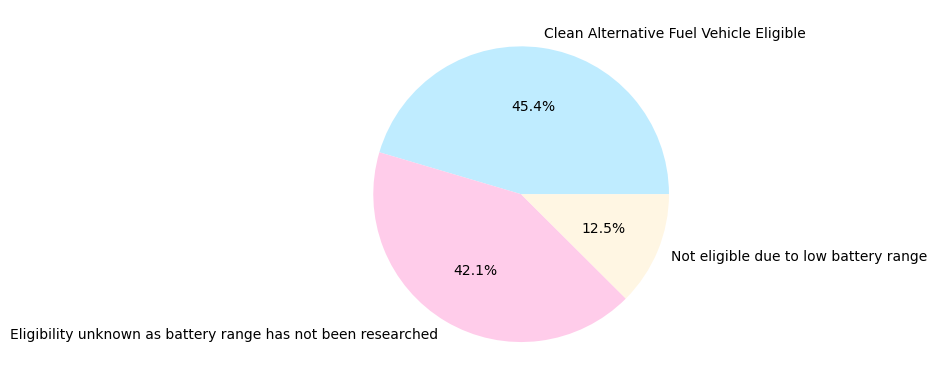

In [57]:
plt.pie(df['CAFV'].value_counts(), labels=df['CAFV'].value_counts().index, autopct='%1.1f%%', colors=['#BFECFF', '#FFCCEA', '#FFF6E3'])
plt.show()

One class is not properly distributed, we will take a stratified split. Split will be 20/80

In [58]:
X = df.drop('CAFV', axis=1)
y = df['CAFV']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
X_train.head(2)

,City,Model Year,Model,BEV Range,PHEV Range,Digit1,Digit2,Digit3,distance_from_center
10233,Renton,2023,ARIYA,NaN,NaN,0,5,6,7.533396
26157,Woodland,2021,MODEL 3,NaN,NaN,6,7,4,178.520676


In [61]:
X_test.head(2)

,City,Model Year,Model,BEV Range,PHEV Range,Digit1,Digit2,Digit3,distance_from_center
5739,Mercer Island,2018,MODEL S,249.0,0.0,0,4,0,16.755492
63090,Olympia,2017,BOLT EV,238.0,0.0,5,0,1,77.004438


In [62]:
y_train.head(2)

10233    Eligibility unknown as battery range has not b...
26157    Eligibility unknown as battery range has not b...
Name: CAFV, dtype: object

In [63]:
y_test.head(2)

5739     Clean Alternative Fuel Vehicle Eligible
63090    Clean Alternative Fuel Vehicle Eligible
Name: CAFV, dtype: object

# **Feature Imputation, Encoding & Scaling**

In [64]:
class CustomMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.medians = None

    def fit(self, X, y=None):
        X = np.array(X)
        self.medians = np.apply_along_axis(
            lambda col: np.median(col[(col > 0) & ~np.isnan(col)]) if np.any((col > 0) & ~np.isnan(col)) else 0,
            axis=0,
            arr=X
        )
        return self
    def transform(self, X, y=None):
        X = np.array(X)

        X_copy = X.copy()
        for i in range(X.shape[1]):
            X_copy[:, i] = np.where((X_copy[:, i] == 0) | np.isnan(X_copy[:, i]), self.medians[i], X_copy[:, i])
        return X_copy

In [65]:
class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X.toarray()

In [74]:
numeric_features = ['BEV Range', 'PHEV Range']
categorical_features = ['City', 'Model Year', 'Model', 'Digit1', 'Digit2', 'Digit3']
numeric_transformer = Pipeline(steps=[('imputer', CustomMedianImputer()), ('scaler', StandardScaler())])
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('dense', DenseTransformer()) ,('pca', PCA(n_components=18))])
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)
set_config(display = 'diagram')

In [75]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   CustomMedianImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BEV Range', 'PHEV Range']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Model Year',
                                                   'Model', 'Digit1', 'Digit2',
                                                   'Digit3'])])),
                ('dense', DenseTransformer()), ('pca', PCA(n_components=18))])

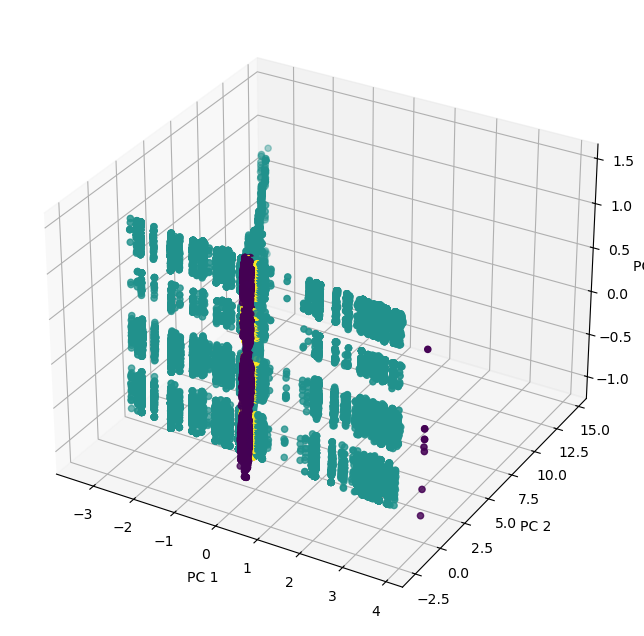

In [67]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


unique_labels = list(set(y_train))
colors = plt.cm.get_cmap('viridis', len(unique_labels))
label_to_color = {label: colors(i) for i, label in enumerate(unique_labels)}


label_colors = [label_to_color[label] for label in y_train]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train_transformed[:, 0], X_train_transformed[:, 1], X_train_transformed[:, 2], c=label_colors)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')

plt.show()

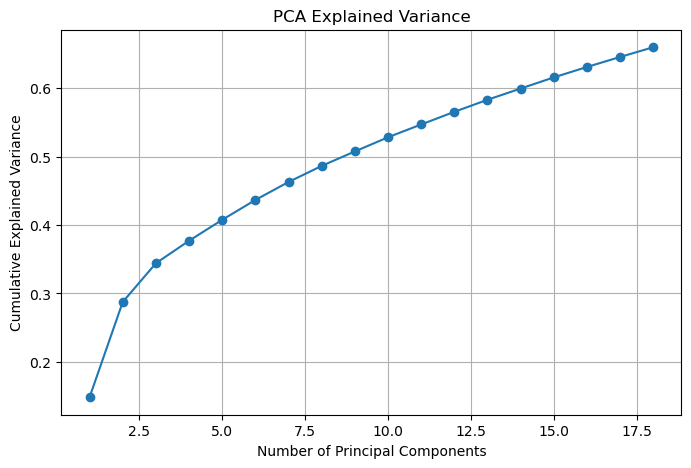

Explained Variance Ratio for each component: [0.14831966 0.13921302 0.05663844 0.03289642 0.03057536 0.02906066
 0.02622931 0.02352845 0.02114905 0.02069638 0.01872188 0.01848446
 0.01763456 0.01639628 0.01631187 0.01520455 0.01464191 0.01427181]
Cumulative Explained Variance: [0.14831966 0.28753268 0.34417112 0.37706755 0.40764291 0.43670357
 0.46293288 0.48646133 0.50761038 0.52830676 0.54702864 0.5655131
 0.58314766 0.59954393 0.61585581 0.63106036 0.64570226 0.65997407]


In [68]:
pca = pipeline.named_steps['pca']
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print("Explained Variance Ratio for each component:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", cumulative_variance)

# **Model Training**

In [69]:
models = {
    'Logistic Regression': LogisticRegression(solver = 'lbfgs', C = 100),
    'Naive Bayes': GaussianNB(var_smoothing= 1e-06),
    'Decision Tree': DecisionTreeClassifier(min_samples_split = 10, min_samples_leaf = 4, max_depth = 5, criterion = 'gini'),
    'KNN': KNeighborsClassifier(weights = 'uniform', n_neighbors = 8, metric = 'cosine'),
    'Random Forest': RandomForestClassifier(n_estimators= 20, min_samples_split= 10, min_samples_leaf= 1, max_depth= 7),
    'AdaBoost': AdaBoostClassifier(n_estimators = 50, learning_rate = 0.5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 25, max_depth = 2, learning_rate = 0.1),
    'SVM': SVC(kernel = 'rbf', gamma = 'auto', C = 1),
    'Neural Network': MLPClassifier(solver= 'sgd', learning_rate= 'adaptive', hidden_layer_sizes= (20,), alpha= 0.001, activation= 'tanh')
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy of {name}: {accuracy:.3f}")
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    print(f"F1-micro of {name}: {f1_micro:.3f}")
    print(f"F1-macro of {name}: {f1_macro:.3f}")
    print(f"F1-weighted of {name}: {f1_weighted:.3f}")

    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print()

Accuracy of Logistic Regression: 0.949
F1-micro of Logistic Regression: 0.949
F1-macro of Logistic Regression: 0.945
F1-weighted of Logistic Regression: 0.949
AUC for Logistic Regression: 0.9857
                                                              precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       0.95      0.95      0.95     12216
Eligibility unknown as battery range has not been researched       0.93      0.97      0.95     11324
                       Not eligible due to low battery range       1.00      0.87      0.93      3355

                                                    accuracy                           0.95     26895
                                                   macro avg       0.96      0.93      0.94     26895
                                                weighted avg       0.95      0.95      0.95     26895

[[11621   595     0]
 [  334 10990     0]
 [  252   183  2920]]

Accuracy of Naive Bayes

# **Hyper Tuning**

In [70]:
classifiers = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear']
    }),
    "GaussianNB": (GaussianNB(), {
        'var_smoothing': np.logspace(-9, -6, 10)
    }),
    "Decision Tree": (DecisionTreeClassifier(), {
        'max_depth': [None, 5, 10, 15, 20, 25, 30],
        'min_samples_split': [2, 4, 8, 10, 12],
        'min_samples_leaf': [1, 2, 4, 6],
        'criterion': ['gini', 'entropy']
    }),
    "KNN": (KNeighborsClassifier(), {
        'n_neighbors': [3, 5, 7, 9, 10, 15, 20],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine']
    }),
    "Random Forest": (RandomForestClassifier(random_state=42), {
        'n_estimators': [5, 10, 15, 20, 25, 30],
        'max_depth': [None, 5, 6, 7, 8, 10, 15, 20],
        'min_samples_split': [2, 5, 10, 12, 6, 4],
        'min_samples_leaf': [1, 2, 4, 6]
    }),
    "AdaBoost": (AdaBoostClassifier(random_state=42), {
        'n_estimators': [25, 35, 50, 75, 100, 20, 15],
        'learning_rate': [0.01, 0.1, 0.5, 1]
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), {
        'n_estimators': [25, 35, 45, 75, 85, 100, 20],
        'learning_rate': [0.01, 0.1, 0.5, 1],
        'max_depth': [3, 5, 7, 2, 8]
    }),
    "SVM": (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10 , 15],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }),
    "MLPClassifier": (MLPClassifier(max_iter=500, random_state=42), {
        'hidden_layer_sizes': [(5,), (10,), (20,), (30,), (50, 50)],
        'activation': ['tanh', 'relu'],
        'solver': ['sgd', 'adam'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive']
    })
}


def hyperparameter_tuning(classifiers, X_train, y_train, max_accuracy=0.9750):
    best_models = {}
    for name, (model, param_grid) in classifiers.items():
        print(f"\n{'=' * 50}")
        print(f"✨ Starting hyperparameter tuning for {name} ✨")
        print(f"{'=' * 50}")

        search = RandomizedSearchCV(
            model,
            param_distributions=param_grid,
            n_iter=30,
            cv=5,
            scoring='accuracy',
            verbose=0,
            n_jobs=-1,
            random_state=42
        )

        search.fit(X_train, y_train)


        results = search.cv_results_
        sorted_indices = np.argsort(results["mean_test_score"])[::-1]

        best_score = None
        best_params = None
        current_best = 0

        for epoch, idx in enumerate(sorted_indices, start=1):
            score = results["mean_test_score"][idx]
            params = results["params"][idx]

            print(f"Epoch {epoch}:")
            print(f"  - Testing parameters: {params}")
            print(f"  - Accuracy: {score:.4f}")

            if score > current_best:
                print(f"  ✅ New best accuracy so far: {score:.4f}")
                current_best = score

            if score <= max_accuracy:
                best_score = score
                best_params = params
                print(f"  🌟 Acceptable parameters found at epoch {epoch}!")
                break

        if best_score is None:
            print(f"❌ Could not find suitable parameters for {name} under the accuracy threshold.")
        else:
            print(f"✨ Best score for {name}: {best_score:.4f}")
            print(f"✨ Best parameters for {name}: {best_params}")
            best_models[name] = model.set_params(**best_params)

    return best_models

print("🚀 Hyperparameter tuning starting...\n")
best_models = hyperparameter_tuning(classifiers, X_train_transformed, y_train)
print("\n🏁 Hyperparameter tuning completed.")
print("\n🎉 Final Models and Parameters:")
for model_name, model in best_models.items():
    print(f"  - {model_name}: {model}")

🚀 Hyperparameter tuning starting...


✨ Starting hyperparameter tuning for Logistic Regression ✨
Epoch 1:
  - Testing parameters: {'solver': 'lbfgs', 'C': 100}
  - Accuracy: 0.9486
  ✅ New best accuracy so far: 0.9486
  🌟 Acceptable parameters found at epoch 1!
✨ Best score for Logistic Regression: 0.9486
✨ Best parameters for Logistic Regression: {'solver': 'lbfgs', 'C': 100}

✨ Starting hyperparameter tuning for GaussianNB ✨
Epoch 1:
  - Testing parameters: {'var_smoothing': 4.6415888336127725e-07}
  - Accuracy: 0.8253
  ✅ New best accuracy so far: 0.8253
  🌟 Acceptable parameters found at epoch 1!
✨ Best score for GaussianNB: 0.8253
✨ Best parameters for GaussianNB: {'var_smoothing': 4.6415888336127725e-07}

✨ Starting hyperparameter tuning for Decision Tree ✨
Epoch 1:
  - Testing parameters: {'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 15, 'criterion': 'entropy'}
  - Accuracy: 0.9973
  ✅ New best accuracy so far: 0.9973
Epoch 2:
  - Testing parameters: {'min_samples